In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 9532137068322443830
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 1484956878
locality {
  bus_id: 1
  links {
  }
}
incarnation: 14277497097775711186
physical_device_desc: "device: 0, name: NVIDIA GeForce MX150, pci bus id: 0000:01:00.0, compute capability: 6.1"
xla_global_id: 416903419
]


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf
import cv2
import os

In [2]:
cut_off=256
offset=256

wd='Cleaned ECG'
File_Names=os.listdir(wd)
imagees_org=[]
imagees_clean=[]

for File_Name in File_Names:
    # for Original Images as X for training

    img=cv2.imread('Data/Cropped Reports/'+File_Name,0)


    cropped_image_orginal=tf.image.resize(img.reshape(img.shape[0],img.shape[1],1),[256,2048])


    for i in range(8):
        imagees_org.append(cropped_image_orginal[:,i*cut_off:cut_off+i*offset])

    # for Cleaned Images as Y for training

    img = cv2.imread('Cleaned ECG/'+File_Name,0)


    cropped_image_clean=tf.image.resize(img.reshape(img.shape[0],img.shape[1],1),[256,2048])


    for i in range(8):
        imagees_clean.append(cropped_image_clean[:,i*cut_off:cut_off+i*offset])

images_org=np.stack(imagees_org,axis=0)
images_clean=np.stack(imagees_clean,axis=0)

In [4]:
images_clean.shape

(2536, 256, 256, 1)

In [3]:
# images_org=images_org.reshape(len(images_org),199,256,1).astype('float32')
# images_clean=images_clean.reshape(len(images_clean),199,256,1).astype('float32')

images_org=images_org/255
images_clean=images_clean/255

In [8]:
range_size=images_clean.shape[0]
train_percent=0.8
train_list=random.sample(range(range_size),int(range_size*train_percent))
test_list=list(set(range(range_size))-set(train_list))
train_image_org=images_org[train_list]
train_image_clean=images_clean[train_list]
test_image_org=images_org[test_list]
test_image_clean=images_clean[test_list]

In [31]:
np.save('clean',images_clean)
np.save('orginal',images_org)

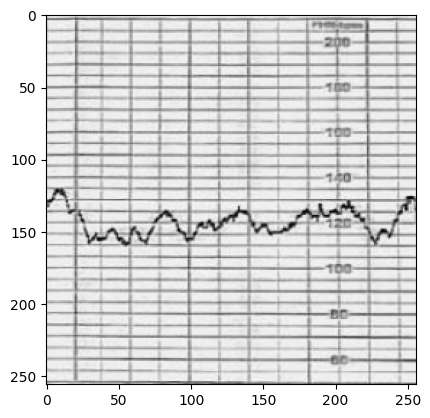

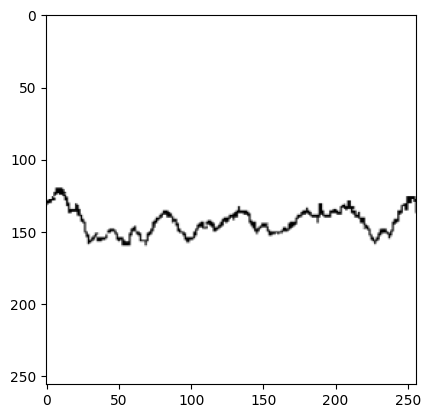

In [173]:
# Sanity check
index=np.random.randint(0,images_clean.shape[0])

plt.imshow(images_org[index],cmap='gray')
plt.show()
plt.imshow(images_clean[index],cmap='gray')
plt.show()

In [10]:

IMG_HEIGHT = images_clean.shape[1]
IMG_WIDTH  = images_clean.shape[2]
IMG_CHANNELS = images_clean.shape[3]

input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [11]:
input_shape

(256, 256, 1)

In [2]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.optimizers import Adam
from keras.layers import Activation, MaxPool2D, Concatenate


def conv_block(input, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)   #Not in the original network.
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)  #Not in the original network
    x = Activation("relu")(x)

    return x

#Encoder block: Conv block followed by maxpooling


def encoder_block(input, num_filters):
    x = conv_block(input, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

#Decoder block
#skip features gets input from encoder for concatenation

def decoder_block(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

#Build Unet using the blocks
def build_unet(input_shape, n_classes):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024) #Bridge

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    if n_classes == 1:  #Binary
      activation = 'sigmoid'
    else:
      activation = 'softmax'

    outputs = Conv2D(n_classes, 1, padding="same", activation=activation)(d4)  #Change the activation based on n_classes
    print(activation)

    model = Model(inputs, outputs, name="U-Net")
    return model

In [14]:
model = build_unet(input_shape, n_classes=1)
model.compile(optimizer=Adam(learning_rate = 1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[3,3,512,1024] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:StatelessRandomUniformV2]

In [14]:
history=model.fit(images_org,images_clean,
                      batch_size=16,
                      verbose=1,
                      epochs=100,
                      validation_data=(images_org,images_clean),
                      shuffle=False



Epoch 1/100


ResourceExhaustedError: in user code:

    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 997, in train_step
        self.optimizer.minimize(loss, self.trainable_variables, tape=tape)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\optimizers\optimizer_v2\optimizer_v2.py", line 579, in minimize
        return self.apply_gradients(grads_and_vars, name=name)
    File "C:\ProgramData\anaconda3\envs\tf

In [1]:
import tensorflow as tf
loaded_model = tf.keras.models.load_model("model.keras")

OSError: Unable to synchronously open file (file signature not found)